In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = "{:,.2f}".format

# Анализ поведения пользователей интернет-магазина за неделю 7–13 октября 2019

## Основное внимание уделяется:

1. Построению и исследованию пользовательской воронки (просмотры → добавления в корзину → покупки).  
2. Выявлению категорий товаров с наибольшей конверсией и выручкой.  
3. Анализу активности пользователей по дням недели и часам суток.  
4. Сегментации пользователей для определения ключевых и наиболее ценных клиентов.


# Подготовка данных

In [2]:
df = pd.read_csv('data/2019-Oct.csv')

In [3]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-07 00:00:01,view,28719604,2053013565228450757,apparel.shoes,baden,89.84,518691953,e414b6be-f264-459b-95bf-bb2aee10c9e5
1,2019-10-07 00:00:01,view,28715802,2116907519078040377,apparel.shoes,NaN,128.45,512539609,77e4ea12-0a86-4f69-bf5d-9d31981b1cc7
2,2019-10-07 00:00:01,view,29900073,2059484601444729123,NaN,peda,900.92,557532288,6de19b7b-940d-4c77-93b4-47fab0eb288e
3,2019-10-07 00:00:01,view,23300110,2053013561956893455,NaN,NaN,33.15,551898979,3f5dbb96-c6f1-4095-bc90-80ba1eb01957
4,2019-10-07 00:00:02,view,22700079,2053013556168753601,NaN,stels,90.09,557530922,1181e883-eb0e-419b-af5e-7a9ea08e3ff7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9817094 entries, 0 to 9817093
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 674.1+ MB


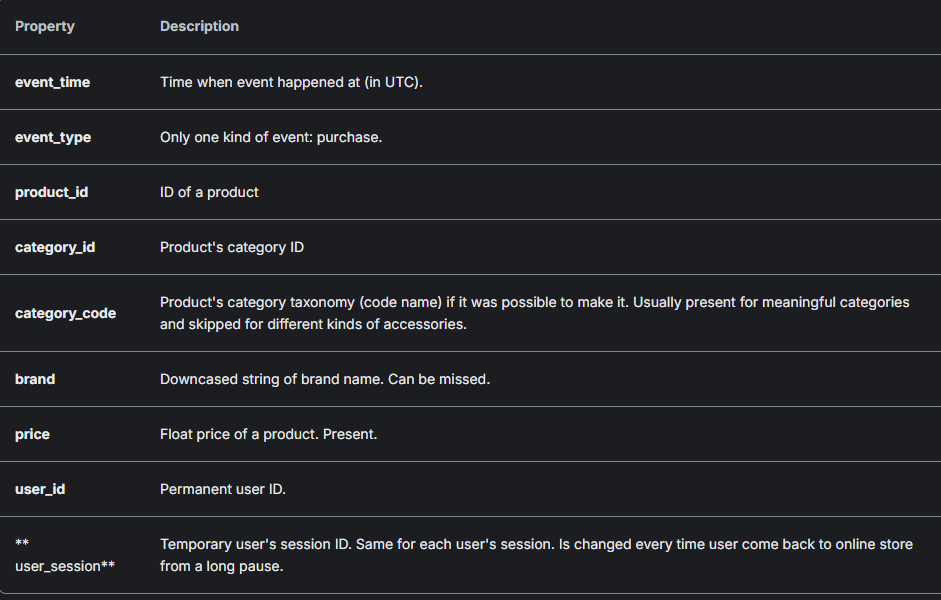

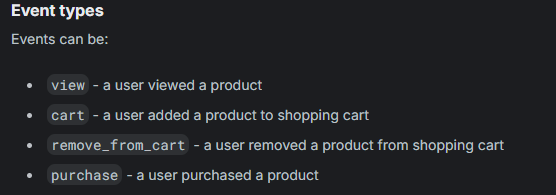

In [5]:
# Преобразуем event_time в datetime
df['event_time'] = pd.to_datetime(df['event_time'])

In [6]:
#Проверимм пропуски в данных
df.isna().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    3427817
brand            1466466
price                  0
user_id                0
user_session           0
dtype: int64

In [7]:
#Создадим категорию unknown для товаров без категории
df['category_code'] = df['category_code'].fillna('unknown')

In [8]:
# Создадим категорию unknown для товаров без бренда
df['brand'] = df['brand'].fillna('unknown')

# Обзор данных 

In [9]:
print("Количество уникальных пользователей:", df['user_id'].nunique())
print("Количество уникальных сессий:", df['user_session'].nunique())
print("Количество категорий (текстовое название):", df['category_code'].nunique())
print("Количество категорий:", df['category_id'].nunique())
print("Количество брендов:", df['brand'].nunique())
print("Количество продуктов:", df['product_id'].nunique())

Количество уникальных пользователей: 1057754
Количество уникальных сессий: 2131505
Количество категорий (текстовое название): 125
Количество категорий: 578
Количество брендов: 2722
Количество продуктов: 124526


## Посмотрим как распределена цена

<Axes: xlabel='price', ylabel='Count'>

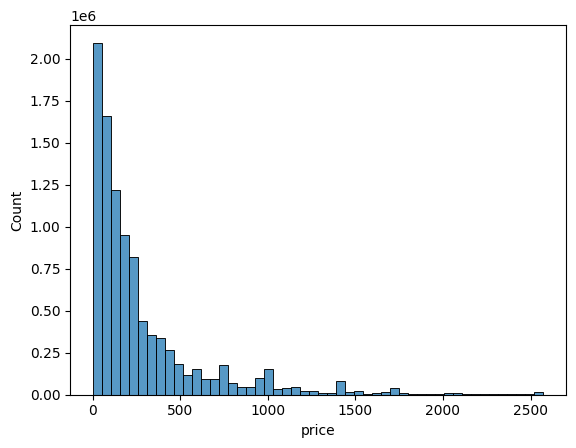

In [57]:

sns.histplot(df['price'], bins = 50)

In [11]:
df['price'].describe()

count   9,817,094.00
mean          283.72
std           363.05
min             0.00
25%            61.57
50%           153.85
75%           338.49
max         2,574.07
Name: price, dtype: float64

Большинство товаров расположены в низком ценовом диапазоне. Есть редкие дорогие позиции, которые создают длинный хвост распределения.

# Рассчитаем пользовательскую воронку

In [12]:

funnel_users = df.groupby('event_type')['user_id'].nunique().reset_index()

funnel_users

,event_type,user_id
0,cart,62257
1,purchase,101241
2,view,1057710


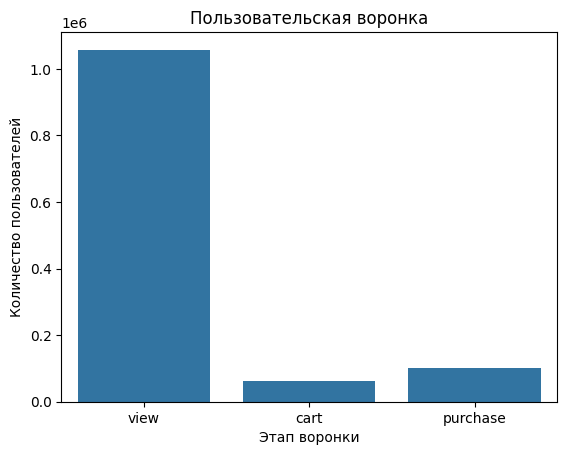

In [13]:
sns.barplot(x=funnel_users['event_type'], y=funnel_users['user_id'], order=['view', 'cart', 'purchase'])
plt.title('Пользовательская воронка')
plt.ylabel('Количество пользователей')
plt.xlabel('Этап воронки')
plt.show()

Можем наблюдать, что кол-во добавлений в корзину меньше чем кол-во покупок. Это может быть вызвано наличием кнопки 'Buy now'. Или же пользователи добавляли какие-то товары в корзину до периода с 7 по 13 октября.

## Рассчитаем конверсии

In [14]:
n_view = funnel_users.loc[funnel_users['event_type']=='view', 'user_id'].values[0]
n_cart = funnel_users.loc[funnel_users['event_type']=='cart', 'user_id'].values[0]
n_purchase = funnel_users.loc[funnel_users['event_type']=='purchase', 'user_id'].values[0]

conv_view_to_cart = n_cart / n_view
conv_cart_to_purchase = n_purchase / n_cart 
conv_view_to_purchase = n_purchase / n_view

print(f"Конверсия view → cart: {conv_view_to_cart:.2%}")
print(f"Конверсия cart → purchase: {conv_cart_to_purchase:.2%}")
print(f"Конверсия view → purchase: {conv_view_to_purchase:.2%}")

Конверсия view → cart: 5.89%
Конверсия cart → purchase: 162.62%
Конверсия view → purchase: 9.57%


# Активность пользователей по дням недели и часам

In [15]:
# Создаем отдельные колонки для дня недели и часа события
df['day_of_week'] = df['event_time'].dt.day_name()
df['hour_of_day'] = df['event_time'].dt.hour

## Рассчитаем активность пользователей по дням недели и по часам

In [16]:
users_by_day = df.groupby('day_of_week')['user_id'].nunique()
users_by_hour = df.groupby('hour_of_day')['user_id'].nunique()

Text(0.5, 1.0, 'Активность пользователей по дням недели')

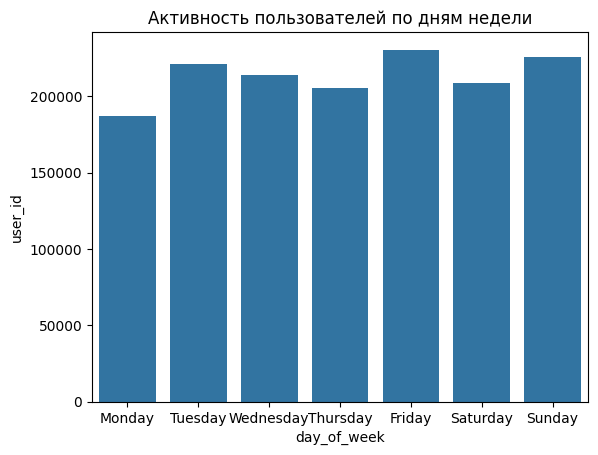

In [46]:
sns.barplot(users_by_day, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Активность пользователей по дням недели')

Так как у нас всего одна неделя в датасете, то есть риск влияния сезонности на результаты. 

Text(0.5, 1.0, 'Активность пользователей по часам')

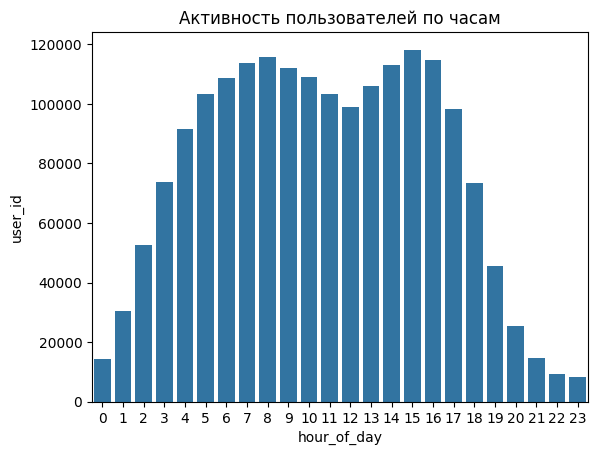

In [47]:
sns.barplot(users_by_hour)
plt.title('Активность пользователей по часам')

Можем наблюдать два пика активности: в районе 8 и 15 часов

## Расссчитаем выручку по дням недели и часам

In [19]:
revenue_by_day = df[df['event_type'] == 'purchase'].groupby('day_of_week')['price'].sum()
revenue_by_hour = df[df['event_type'] == 'purchase'].groupby('hour_of_day')['price'].sum()

Text(0.5, 1.0, 'Выручка по дням недели')

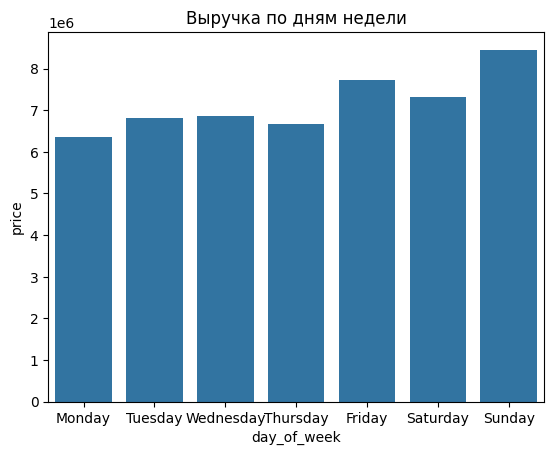

In [48]:
sns.barplot(revenue_by_day, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Выручка по дням недели')

Text(0.5, 1.0, 'Выручка по часам')

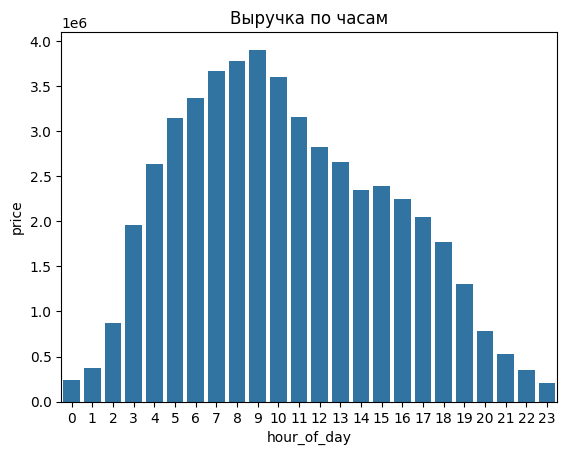

In [50]:
sns.barplot(revenue_by_hour)
plt.title('Выручка по часам')

В отличие от пользовательской активности, выручка имеет выраженный один пик - около 9 часов утра. Вероятно, в это время пользователи чаще совершают покупки, после чего активность начинает снижаться, так как основная часть целевых действий уже выполнена.
Второй пик активности наблюдается ближе к 17 часам, однако он не сопровождается сопоставимым ростом выручки.

Активность пользователей в течение недели распределена относительно равномерно, однако выручка концентрируется в выходные и в конце недели. В воскресенье при сопоставимом числе пользователей формируется максимальная выручка, что указывает на более высокий средний чек.

## Средний чек по дням недели и часам

In [22]:
# Средний чек - выручка / кол-во заказов. Заказ в нашем случае - уникальная сессия
purchase_df = df[df['event_type'] == 'purchase']

avg_check_by_day = purchase_df.groupby('day_of_week').agg(revenue=('price', 'sum'), orders=('user_session', 'nunique'))

avg_check_by_day['avg_check'] = avg_check_by_day['revenue'] / avg_check_by_day['orders']

In [23]:
avg_check_by_hour = purchase_df.groupby('hour_of_day').agg(revenue=('price', 'sum'), orders=('user_session', 'nunique'))

avg_check_by_hour['avg_check'] = avg_check_by_hour['revenue'] / avg_check_by_hour['orders']

Text(0.5, 1.0, 'Средний чек по дням недели')

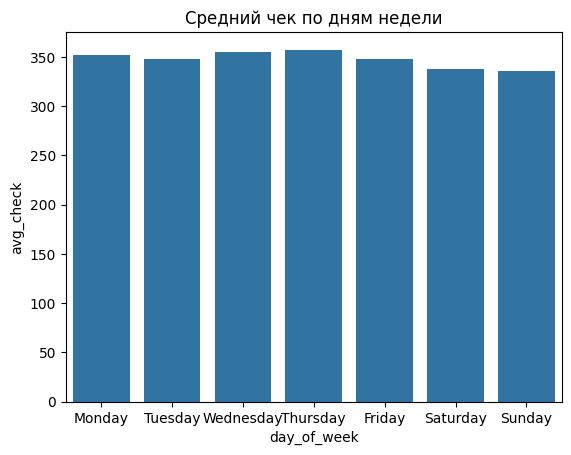

In [51]:
sns.barplot(x = avg_check_by_day.index, y =avg_check_by_day['avg_check'], order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Средний чек по дням недели')

Видим, что средний чек практически не меняется в течении недели

Text(0.5, 1.0, 'Средний чек по часам')

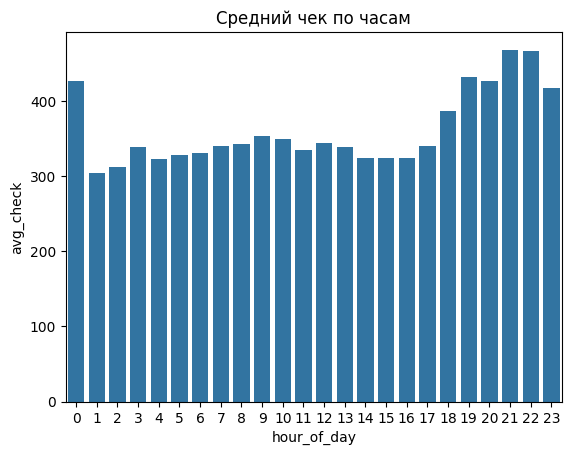

In [53]:
sns.barplot(avg_check_by_hour['avg_check'])
plt.title('Средний чек по часам')

Вечером пользователи делают меньше заходов на сайт, но средний чек значительно выше. То есть те, кто приходит вечером, тратят больше за одну покупку.

## Retention

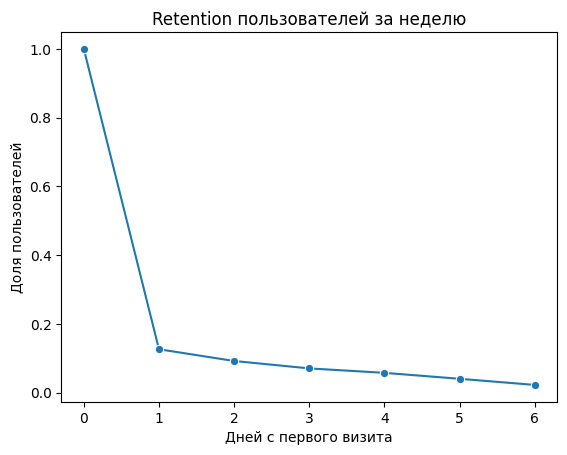

In [26]:
# Добавим день недели и день месяца для удобства
df['day'] = df['event_time'].dt.day

# Определяем первый день визита каждого пользователя
first_visit = df.groupby('user_id')['day'].min().reset_index()
first_visit.columns = ['user_id', 'first_day']

# Объединяем с основным датасетом
df_retention = pd.merge(df, first_visit, on='user_id', how='left')

# Считаем, сколько дней прошло с первого визита
df_retention['days_since_first'] = df_retention['day'] - df_retention['first_day']

# Считаем retention по дням
retention = df_retention.groupby('days_since_first')['user_id'].nunique().reset_index()
retention.columns = ['days_since_first', 'active_users']

# Доля активных пользователей от всех новых пользователей
new_users_count = first_visit['user_id'].nunique()
retention['retention_rate'] = retention['active_users'] / new_users_count

# Визуализация
sns.lineplot(x='days_since_first', y='retention_rate', data=retention, marker='o')
plt.title('Retention пользователей за неделю')
plt.xlabel('Дней с первого визита')
plt.ylabel('Доля пользователей')
plt.xticks(range(0, 7))
plt.show()


# Платящие пользователи

## ARPU, ARPPU

In [27]:
#ARPU
total_revenue = purchase_df['price'].sum()
total_users = df['user_id'].nunique()
ARPU = total_revenue / total_users

#ARPPU
paying_users = purchase_df['user_id'].nunique()
ARPPU = total_revenue / paying_users

print(f"Общий доход за неделю: {total_revenue:,.0f}")
print(f"ARPU: {ARPU:.2f}")
print(f"ARPPU: {ARPPU:.2f}")

Общий доход за неделю: 50,170,640
ARPU: 47.43
ARPPU: 495.56


## Выручка с платящих пользователей

In [28]:
user_spending = purchase_df.groupby('user_id')['price'].sum().reset_index()
user_spending['price'].describe()

count   101,241.00
mean        495.56
std       1,323.16
min           0.88
25%          87.75
50%         200.01
75%         489.05
max     119,800.46
Name: price, dtype: float64

## Количество заказов на пользователей

In [29]:
user_orders = purchase_df.groupby('user_id')['user_session'].nunique().reset_index()


In [30]:
user_orders['user_session'].describe()

count   101,241.00
mean          1.43
std           1.29
min           1.00
25%           1.00
50%           1.00
75%           1.00
max          58.00
Name: user_session, dtype: float64

In [31]:
percent_multi_order_users = (user_orders[user_orders['user_session'] > 1].shape[0] / user_orders.shape[0]) * 100

print(f"Доля пользователей с более чем 1 заказом: {percent_multi_order_users:.2f}%")

Доля пользователей с более чем 1 заказом: 22.54%


In [32]:
#Посчитаем 99% процентиль
np.percentile(user_orders['user_session'],99)

np.float64(6.0)

In [33]:
user_df = user_spending.merge(user_orders, on='user_id')
user_df.columns = ['user_id', 'total_spent', 'num_orders']


In [34]:
revenue_percent = user_df[user_df['num_orders'] >= 6]['total_spent'].sum() / user_df['total_spent'].sum() * 100
print(f"Доля выручки от пользователей с 6 и более заказами: {revenue_percent:.2f}%")

Доля выручки от пользователей с 6 и более заказами: 14.80%


Видим, что аж 15% выручки приходится на 1% пользователей, сделавших 6 и более заказов.

# Анализ категорий и брендов

In [35]:
revenue_by_category = purchase_df.groupby('category_code')['price'].sum().sort_values(ascending=False)

In [36]:
revenue_by_category.head(10)

category_code
electronics.smartphone             33,493,402.31
unknown                             5,933,195.51
computers.notebook                  1,857,825.57
electronics.video.tv                1,656,924.42
electronics.clocks                  1,013,057.02
appliances.kitchen.washer             885,840.81
appliances.kitchen.refrigerators      883,202.68
electronics.audio.headphone           738,822.12
electronics.tablet                    457,529.58
appliances.environment.vacuum         356,132.54
Name: price, dtype: float64

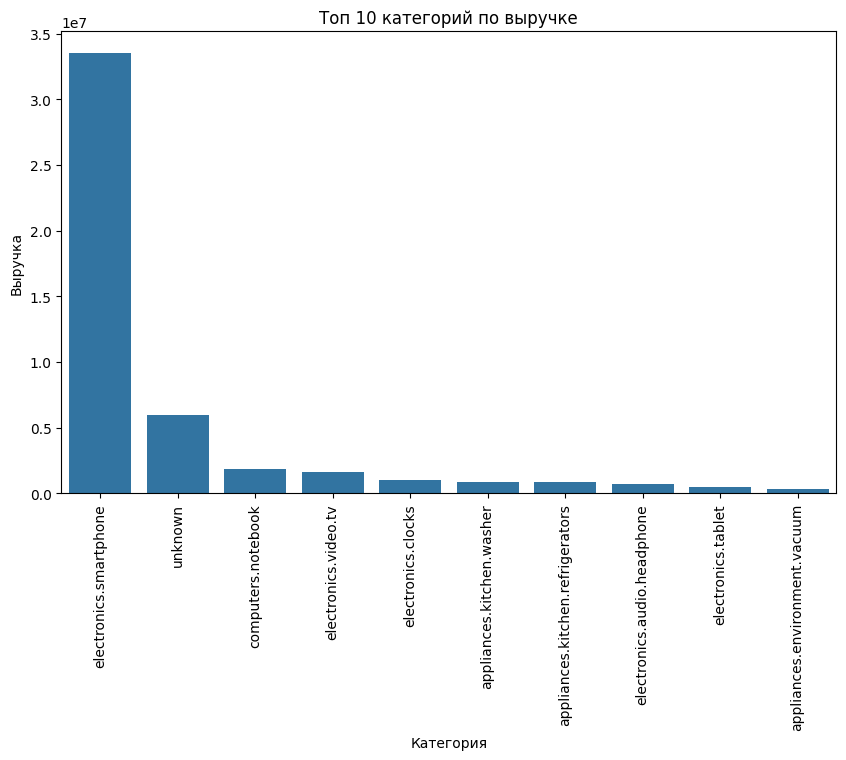

In [55]:
plt.figure(figsize=(10,6))
sns.barplot(revenue_by_category.head(10))
plt.title('Топ 10 категорий по выручке')
plt.xlabel('Категория')
plt.ylabel('Выручка')
plt.xticks(rotation = 90);


In [38]:
smartphone_percent = (revenue_by_category.loc['electronics.smartphone'] / total_revenue) * 100
print(f"Доля выручки от смартфонов: {smartphone_percent:.2f}%")

Доля выручки от смартфонов: 66.76%


Смартфоны приносят основную часть выручки - более 33 млн (66% от общей выручки). Категория unknown даёт почти 6 млн. Дальше идут ноутбуки, телевизоры, часы и бытовая техника, каждая из которых приносит меньше, но всё равно значимую выручку.

In [39]:
revenue_by_brand = purchase_df.groupby('brand')['price'].sum().sort_values(ascending=False)

In [40]:
revenue_by_brand.head(10)

brand
apple     23,600,096.70
samsung    9,798,457.47
unknown    2,079,009.46
xiaomi     2,050,376.02
huawei     1,074,379.37
lucente      822,451.12
acer         659,030.14
lg           652,275.00
sony         496,957.38
lenovo       451,720.73
Name: price, dtype: float64

Text(0, 0.5, 'Выручка')

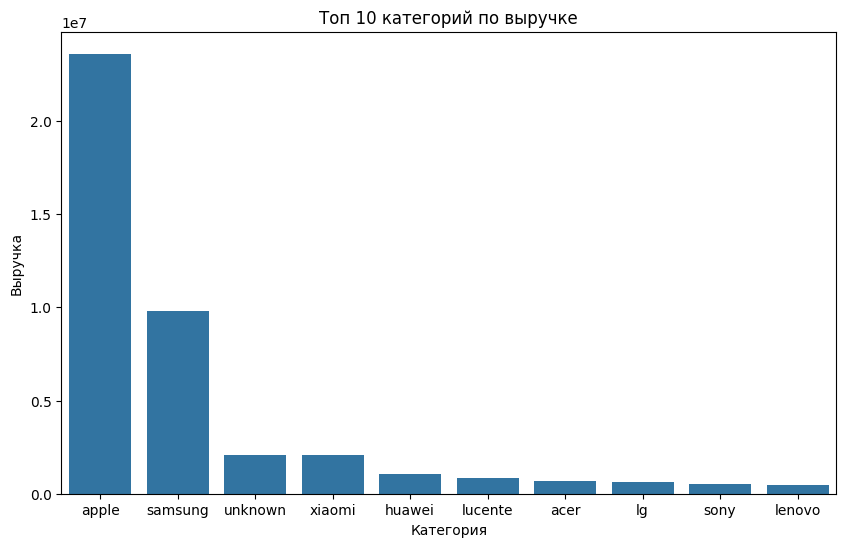

In [56]:
plt.figure(figsize=(10,6))
sns.barplot(revenue_by_brand.head(10))
plt.title('Топ 10 категорий по выручке')
plt.xlabel('Категория')
plt.ylabel('Выручка')

In [42]:
apple_percent = (revenue_by_brand.loc['apple'] / total_revenue) * 100
print(f"Доля выручки от apple: {apple_percent:.2f}%")

Доля выручки от apple: 47.04%


Наибольшую выручку за неделю принесли товары бренда Apple - 23,6 млн (47% от общей выручки), далее Samsung — почти 9,8 млн. Остальные бренды, включая Xiaomi, Huawei, LG, Sony и Lenovo, значительно меньше влияют на общую выручку.

In [43]:
apple_smartphones_revenue = purchase_df[
    (purchase_df['category_code'] == 'electronics.smartphone') & 
    (purchase_df['brand'] == 'apple')
]['price'].sum()

apple_smartphones_share = apple_smartphones_revenue / total_revenue * 100

print(f"Выручка от смартфонов Apple: {apple_smartphones_revenue:,.0f}")
print(f"Доля от общей выручки: {apple_smartphones_share:.2f}%")

Выручка от смартфонов Apple: 21,711,828
Доля от общей выручки: 43.28%


Практически половина дохода за неделю приходится на смартфоны Apple

# Выводы

1) За неделю платформу посетили более 1 млн пользователей, совершив 2 млн сессий. Большинство товаров недорогие, но редкие дорогие позиции создают значительную часть дохода.

2) Конверсия просмотра в добавление в корзину низкая (5.9%), тогда как конверсия в покупку выше ожидаемой (>100%), что указывает на возможность оптимизации корзины и персональных рекомендаций.

3) Активность пользователей пикует утром (8-9 часов) и днём (15-16 часов), однако выручка концентрируется в утренний час. Вечером пользователи заходят реже, но совершают более крупные покупки.

4) ARPU составляет 47.43, ARPPU - 495.56. 1% пользователей с 6+ заказами формируют ~15% выручки, что подчёркивает ценность «суперпокупателей».

5) Наибольший доход приносят смартфоны, особенно Apple (43% от выручки). Топовые бренды концентрируют львиную долю дохода, остальные категории менее прибыльны.

6) Рекомендации: повысить конверсию добавлений в корзину, таргетировать суперпокупателей, планировать маркетинговые активности на утренние пики, а также внедрять персонализированные предложения по категориям и брендам.